
image 1/1 e:\tik tok\Car_Palate\test1.jpg: 320x256 (no detections), 38.8ms
Speed: 0.7ms preprocess, 38.8ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 256)


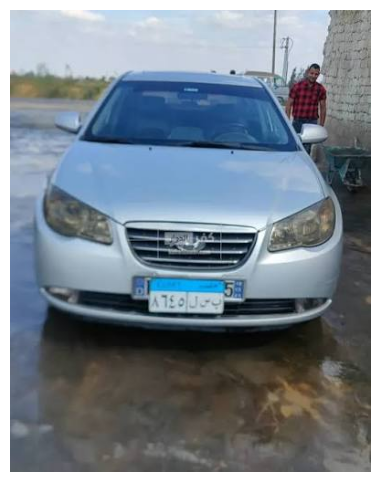

In [5]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
model = YOLO("best_char.pt")
result = model("test1.jpg" , show = True)
res_plotted = result[0].plot()

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


image 1/1 e:\tik tok\Car_Palate\test1.jpg: 640x512 1 License Plate, 60.4ms
Speed: 4.6ms preprocess, 60.4ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 512)

0: 160x320 7 -s, 21.8ms
Speed: 2.0ms preprocess, 21.8ms inference, 0.9ms postprocess per image at shape (1, 3, 160, 320)


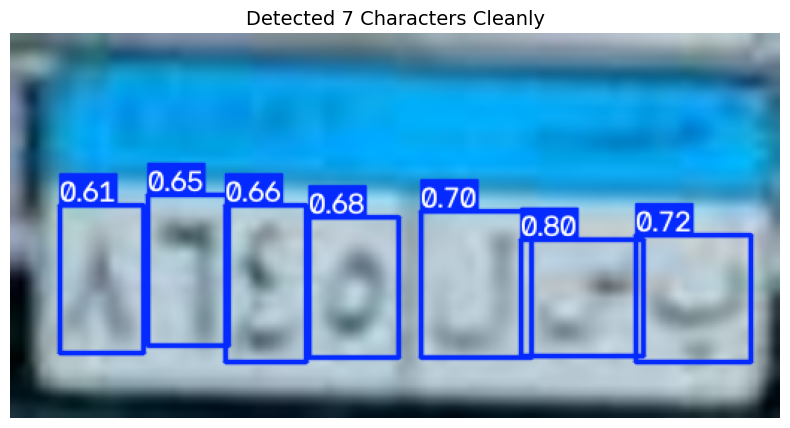

In [9]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. تحميل الموديلين
plate_model = YOLO("best.pt")
char_model = YOLO("best_char.pt")

# 2. كشف مكان اللوحة من صورة السيارة
results_plate = plate_model("test1.jpg")
box = results_plate[0].boxes.xyxy[0]
x1, y1, x2, y2 = map(int, box[:4])

# قص النمرة
plate_crop = results_plate[0].orig_img[y1:y2, x1:x2]

# 3. تكبير أبعاد النمرة (عشان مربعات الحروف ما تغطيش الصورة)
h, w = plate_crop.shape[:2]
plate_large = cv2.resize(plate_crop, (w * 6, h * 6), interpolation=cv2.INTER_CUBIC)

# 4. تشغيل موديل الحروف على النمرة المكبّرة
results_char = char_model(plate_large)

# رسم الصناديق بخطوط رفيعة وأنيقة بدون تشويه (labels=False لإخفاء الشخبطة الزرقاء، أو بدونها)
clean_plot = results_char[0].plot(line_width=2, labels=False)

# 5. عرض النتيجة النظيفة
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(clean_plot, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(results_char[0].boxes)} Characters Cleanly", fontsize=14)
plt.axis("off")
plt.show()



image 1/1 e:\tik tok\Car_Palate\test3.jpg: 640x480 1 License Plate, 65.9ms
Speed: 5.2ms preprocess, 65.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


Using CPU. Note: This module is much faster with a GPU.
C:\Users\Omar\AppData\Roaming\Python\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


النمرة المقروءة بدقة: ط ىج ٨٢٥٤


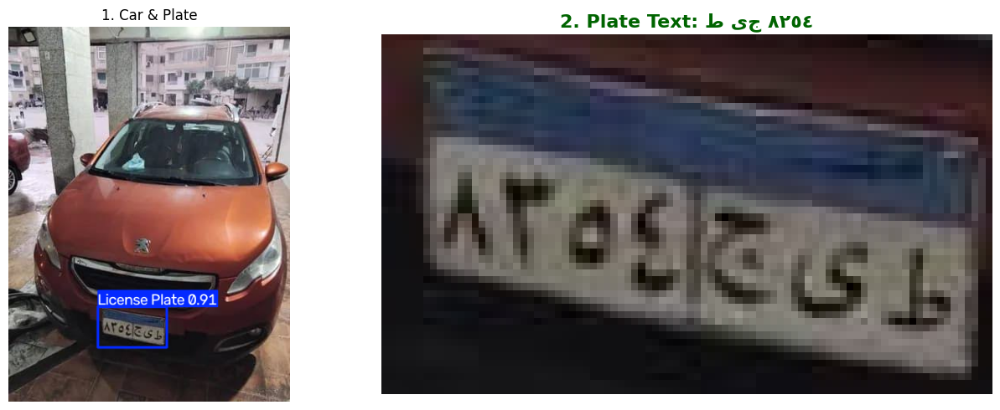

In [12]:
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. كشف النمرة بالموديل الأول
plate_model = YOLO("best.pt")
results = plate_model("test3.jpg")

box = results[0].boxes.xyxy[0]
x1, y1, x2, y2 = map(int, box[:4])
plate_crop = results[0].orig_img[y1:y2, x1:x2]

# 2. قراءة حروف وأرقام النمرة عبر الـ OCR
reader = easyocr.Reader(['ar'], gpu=False)
ocr_res = reader.readtext(plate_crop)

detected_text = " ".join([text for _, text, _ in ocr_res])
print("النمرة المقروءة بدقة:", detected_text)

# 3. عرض النتيجة
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(results[0].plot(line_width=2), cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Car & Plate", fontsize=12)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"2. Plate Text: {detected_text}", fontsize=16, color='darkgreen', weight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.show()



image 1/1 e:\tik tok\Car_Palate\test2.jpg: 448x640 1 License Plate, 48.8ms
Speed: 2.4ms preprocess, 48.8ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)

0: 192x320 1 3, 1 6, 1 7, 1 saad, 2 seens, 22.9ms
Speed: 0.8ms preprocess, 22.9ms inference, 0.8ms postprocess per image at shape (1, 3, 192, 320)
🎯 النمرة المقروءة: ٧ ٣ ٦ ص س س


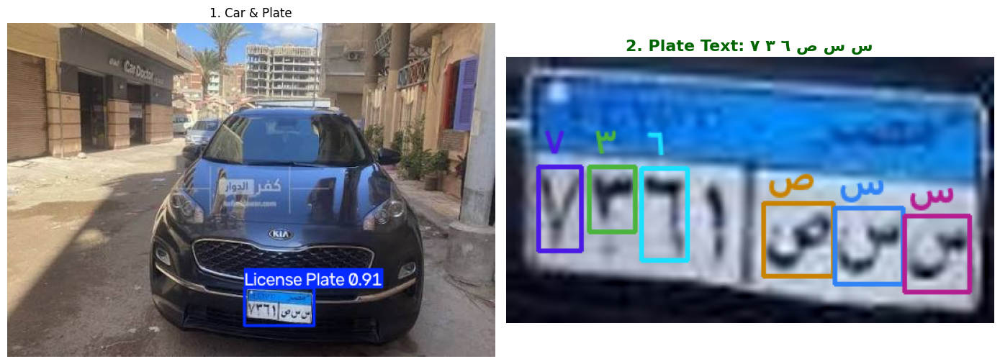

In [21]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. تحميل الموديلين
plate_model = YOLO("best.pt")
char_model = YOLO("Tuning_char.pt")  # الموديل الخرافي الجديد (98.9%)

# 2. قاموس تحويل الكلاسات الصوتية إلى حروف وأرقام عربية نقية
char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

colors = [
    (230, 25, 75), (60, 180, 75), (255, 225, 25), (0, 130, 200),
    (245, 130, 48), (145, 30, 180), (70, 240, 240), (240, 50, 230)
]

# 3. اختبار على السيارة (test3.jpg)
image_path = "test2.jpg"
plate_results = plate_model(image_path)
orig_img = plate_results[0].orig_img

box = plate_results[0].boxes.xyxy[0]
x1, y1, x2, y2 = map(int, box[:4])

# قص النمرة وتكبيرها
plate_crop = orig_img[y1:y2, x1:x2]
h, w = plate_crop.shape[:2]
plate_large = cv2.resize(plate_crop, (w * 4, h * 4), interpolation=cv2.INTER_CUBIC)

# 4. كشف الحروف بدقة
char_results = char_model(plate_large, conf=0.35, iou=0.4)
boxes = char_results[0].boxes

# فرز الحروف من اليسار إلى اليمين
sorted_idx = sorted(range(len(boxes)), key=lambda k: boxes.xyxy[k][0])

annotated_plate = plate_large.copy()
recognized_chars = []

for i, idx in enumerate(sorted_idx):
    bx1, by1, bx2, by2 = map(int, boxes.xyxy[idx][:4])
    cls_id = int(boxes.cls[idx].item())
    raw_name = char_model.names[cls_id]
    arabic_name = char_map.get(raw_name, raw_name)
    color = colors[i % len(colors)]
    
    cv2.rectangle(annotated_plate, (bx1, by1), (bx2, by2), color, 2)
    cv2.putText(annotated_plate, arabic_name, (bx1 + 3, max(25, by1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    recognized_chars.append(arabic_name)

plate_text = " ".join(recognized_chars)
print(f"🎯 النمرة المقروءة: {plate_text}")

# 5. عرض النتيجة
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(plate_results[0].plot(line_width=2), cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Car & Plate", fontsize=12)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated_plate, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"2. Plate Text: {plate_text}", fontsize=16, color='darkgreen', weight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.show()



image 1/1 e:\tik tok\Car_Palate\test1.jpg: 640x512 1 License Plate, 57.1ms
Speed: 2.5ms preprocess, 57.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 512)

0: 160x320 1 5, 1 6, 1 8, 1 ain, 1 baa, 1 qaaf, 21.1ms
Speed: 0.6ms preprocess, 21.1ms inference, 1.1ms postprocess per image at shape (1, 3, 160, 320)
🎯 النمرة المقروءة: ٨ ٦ ع ٥ ق ب


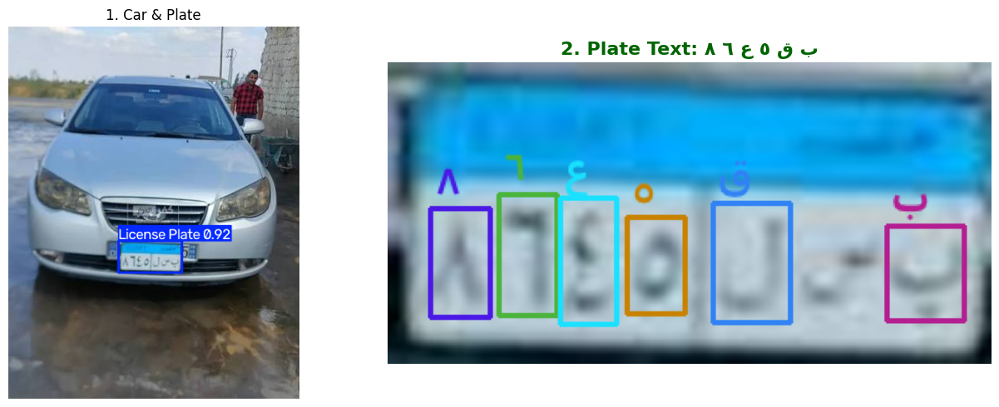

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. تحميل الموديلين
plate_model = YOLO("best.pt")
char_model = YOLO("Tuning_char.pt")  # الموديل الخرافي الجديد (98.9%)

# 2. قاموس تحويل الكلاسات الصوتية إلى حروف وأرقام عربية نقية
char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

colors = [
    (230, 25, 75), (60, 180, 75), (255, 225, 25), (0, 130, 200),
    (245, 130, 48), (145, 30, 180), (70, 240, 240), (240, 50, 230)
]

# 3. اختبار على السيارة (test3.jpg)
image_path = "test1.jpg"
plate_results = plate_model(image_path)
orig_img = plate_results[0].orig_img

box = plate_results[0].boxes.xyxy[0]
x1, y1, x2, y2 = map(int, box[:4])

# قص النمرة وتكبيرها
plate_crop = orig_img[y1:y2, x1:x2]
h, w = plate_crop.shape[:2]
plate_large = cv2.resize(plate_crop, (w * 4, h * 4), interpolation=cv2.INTER_CUBIC)

# 4. كشف الحروف بدقة
char_results = char_model(plate_large, conf=0.35, iou=0.4)
boxes = char_results[0].boxes

# فرز الحروف من اليسار إلى اليمين
sorted_idx = sorted(range(len(boxes)), key=lambda k: boxes.xyxy[k][0])

annotated_plate = plate_large.copy()
recognized_chars = []

for i, idx in enumerate(sorted_idx):
    bx1, by1, bx2, by2 = map(int, boxes.xyxy[idx][:4])
    cls_id = int(boxes.cls[idx].item())
    raw_name = char_model.names[cls_id]
    arabic_name = char_map.get(raw_name, raw_name)
    color = colors[i % len(colors)]
    
    cv2.rectangle(annotated_plate, (bx1, by1), (bx2, by2), color, 2)
    cv2.putText(annotated_plate, arabic_name, (bx1 + 3, max(25, by1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    recognized_chars.append(arabic_name)

plate_text = " ".join(recognized_chars)
print(f"🎯 النمرة المقروءة: {plate_text}")

# 5. عرض النتيجة
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(plate_results[0].plot(line_width=2), cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Car & Plate", fontsize=12)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated_plate, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"2. Plate Text: {plate_text}", fontsize=16, color='darkgreen', weight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.show()



image 1/1 e:\tik tok\Car_Palate\test4.png: 288x640 1 License Plate, 63.4ms
Speed: 2.0ms preprocess, 63.4ms inference, 0.9ms postprocess per image at shape (1, 3, 288, 640)

0: 192x320 1 1, 1 5, 1 6, 1 faa, 1 jeem, 21.1ms
Speed: 0.8ms preprocess, 21.1ms inference, 0.9ms postprocess per image at shape (1, 3, 192, 320)
🎯 النمرة المقروءة: ٦ ١ ٥ ج ف


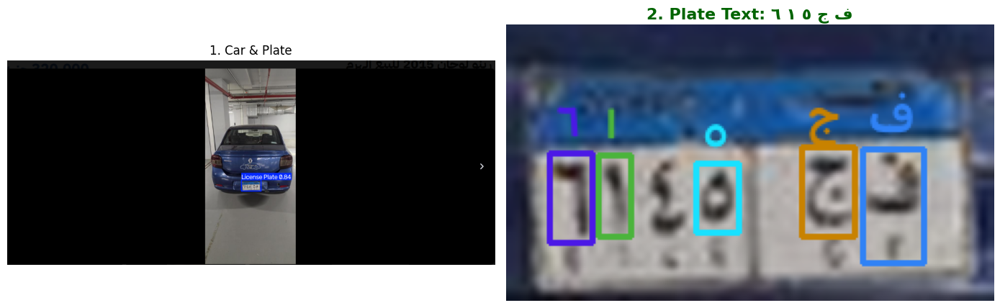

In [16]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. تحميل الموديلين
plate_model = YOLO("best.pt")
char_model = YOLO("Tuning_char.pt")  # الموديل الخرافي الجديد (98.9%)

# 2. قاموس تحويل الكلاسات الصوتية إلى حروف وأرقام عربية نقية
char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

colors = [
    (230, 25, 75), (60, 180, 75), (255, 225, 25), (0, 130, 200),
    (245, 130, 48), (145, 30, 180), (70, 240, 240), (240, 50, 230)
]

# 3. اختبار على السيارة (test3.jpg)
image_path = "test4.png"
plate_results = plate_model(image_path)
orig_img = plate_results[0].orig_img

box = plate_results[0].boxes.xyxy[0]
x1, y1, x2, y2 = map(int, box[:4])

# قص النمرة وتكبيرها
plate_crop = orig_img[y1:y2, x1:x2]
h, w = plate_crop.shape[:2]
plate_large = cv2.resize(plate_crop, (w * 4, h * 4), interpolation=cv2.INTER_CUBIC)

# 4. كشف الحروف بدقة
char_results = char_model(plate_large, conf=0.35, iou=0.4)
boxes = char_results[0].boxes

# فرز الحروف من اليسار إلى اليمين
sorted_idx = sorted(range(len(boxes)), key=lambda k: boxes.xyxy[k][0])

annotated_plate = plate_large.copy()
recognized_chars = []

for i, idx in enumerate(sorted_idx):
    bx1, by1, bx2, by2 = map(int, boxes.xyxy[idx][:4])
    cls_id = int(boxes.cls[idx].item())
    raw_name = char_model.names[cls_id]
    arabic_name = char_map.get(raw_name, raw_name)
    color = colors[i % len(colors)]
    
    cv2.rectangle(annotated_plate, (bx1, by1), (bx2, by2), color, 2)
    cv2.putText(annotated_plate, arabic_name, (bx1 + 3, max(25, by1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    recognized_chars.append(arabic_name)

plate_text = " ".join(recognized_chars)
print(f"🎯 النمرة المقروءة: {plate_text}")

# 5. عرض النتيجة
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(plate_results[0].plot(line_width=2), cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Car & Plate", fontsize=12)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated_plate, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"2. Plate Text: {plate_text}", fontsize=16, color='darkgreen', weight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.show()



image 1/1 e:\tik tok\Car_Palate\test2.jpg: 448x640 1 License Plate, 66.5ms
Speed: 2.8ms preprocess, 66.5ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)

0: 192x320 1 3, 1 6, 1 7, 1 saad, 2 seens, 20.4ms
Speed: 0.7ms preprocess, 20.4ms inference, 0.9ms postprocess per image at shape (1, 3, 192, 320)
🎯 النمرة المقروءة: ٧ ٣ ٦ ص س س


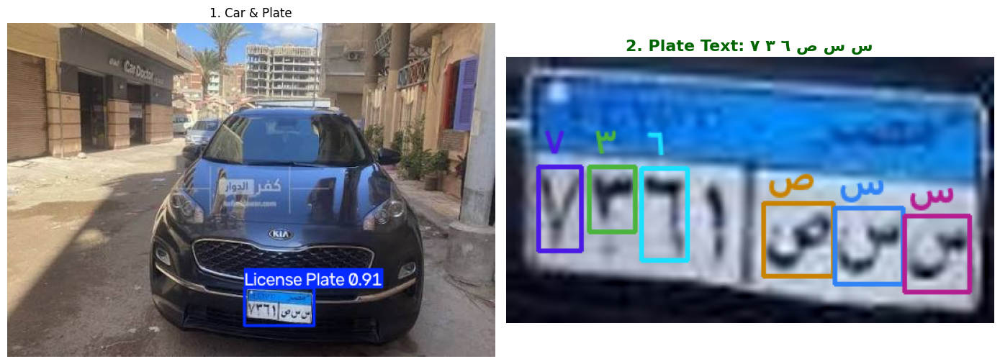

In [17]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. تحميل الموديلين
plate_model = YOLO("best.pt")
char_model = YOLO("Tuning_char.pt")  # الموديل الخرافي الجديد (98.9%)

# 2. قاموس تحويل الكلاسات الصوتية إلى حروف وأرقام عربية نقية
char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

colors = [
    (230, 25, 75), (60, 180, 75), (255, 225, 25), (0, 130, 200),
    (245, 130, 48), (145, 30, 180), (70, 240, 240), (240, 50, 230)
]

# 3. اختبار على السيارة (test3.jpg)
image_path = "test2.jpg"
plate_results = plate_model(image_path)
orig_img = plate_results[0].orig_img

box = plate_results[0].boxes.xyxy[0]
x1, y1, x2, y2 = map(int, box[:4])

# قص النمرة وتكبيرها
plate_crop = orig_img[y1:y2, x1:x2]
h, w = plate_crop.shape[:2]
plate_large = cv2.resize(plate_crop, (w * 4, h * 4), interpolation=cv2.INTER_CUBIC)

# 4. كشف الحروف بدقة
char_results = char_model(plate_large, conf=0.35, iou=0.4)
boxes = char_results[0].boxes

# فرز الحروف من اليسار إلى اليمين
sorted_idx = sorted(range(len(boxes)), key=lambda k: boxes.xyxy[k][0])

annotated_plate = plate_large.copy()
recognized_chars = []

for i, idx in enumerate(sorted_idx):
    bx1, by1, bx2, by2 = map(int, boxes.xyxy[idx][:4])
    cls_id = int(boxes.cls[idx].item())
    raw_name = char_model.names[cls_id]
    arabic_name = char_map.get(raw_name, raw_name)
    color = colors[i % len(colors)]
    
    cv2.rectangle(annotated_plate, (bx1, by1), (bx2, by2), color, 2)
    cv2.putText(annotated_plate, arabic_name, (bx1 + 3, max(25, by1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    recognized_chars.append(arabic_name)

plate_text = " ".join(recognized_chars)
print(f"🎯 النمرة المقروءة: {plate_text}")

# 5. عرض النتيجة
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(plate_results[0].plot(line_width=2), cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Car & Plate", fontsize=12)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated_plate, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"2. Plate Text: {plate_text}", fontsize=16, color='darkgreen', weight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.show()



image 1/1 e:\tik tok\Car_Palate\test1.jpg: 640x512 1 License Plate, 52.5ms
Speed: 2.7ms preprocess, 52.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)

0: 160x320 1 5, 1 6, 1 8, 1 baa, 1 faa, 1 qaaf, 23.8ms
Speed: 0.8ms preprocess, 23.8ms inference, 1.0ms postprocess per image at shape (1, 3, 160, 320)
🎯 النمرة المقروءة: ٨ ٦ ٥ ف ق ب


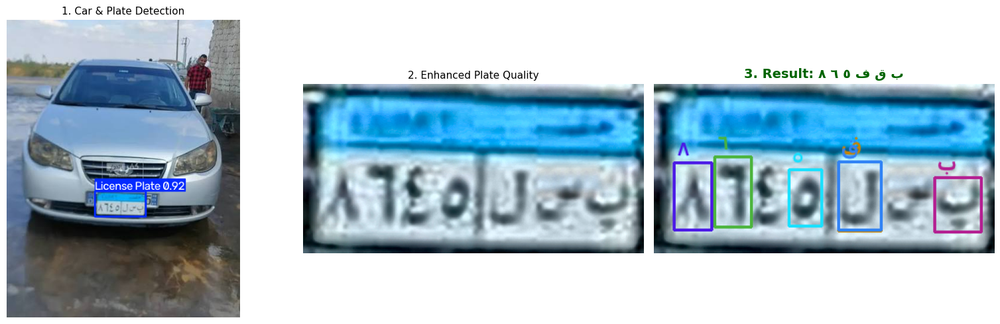

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. تحميل الموديلين (الموديل الخارق الجديد)
plate_model = YOLO("best.pt")
char_model = YOLO("Tuning_char.pt")

# 2. قاموس الحروف والأرقام العربية
char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

colors = [
    (230, 25, 75), (60, 180, 75), (255, 225, 25), (0, 130, 200),
    (245, 130, 48), (145, 30, 180), (70, 240, 240), (240, 50, 230)
]

# -------------------------------------------------------------
# 🛠️ دالة تحسين ومعالجة جودة الصورة وإزالة التشويش
# -------------------------------------------------------------
def enhance_plate(img):
    # 1. تكبير الصورة بخوارزمية Lanczos المتقدمة للحفاظ على التفاصيل
    h, w = img.shape[:2]
    upscaled = cv2.resize(img, (w * 4, h * 4), interpolation=cv2.INTER_LANCZOS4)
    
    # 2. ضبط الإضاءة والتباين عبر فضاء LAB و CLAHE
    lab = cv2.cvtColor(upscaled, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    enhanced_lab = cv2.merge((cl, a, b))
    enhanced_bgr = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    
    # 3. إزالة الضبابية وزيادة حدة الحواف (Unsharp Mask)
    gaussian = cv2.GaussianBlur(enhanced_bgr, (0, 0), 2.0)
    sharpened = cv2.addWeighted(enhanced_bgr, 1.7, gaussian, -0.7, 0)
    
    return sharpened
# -------------------------------------------------------------

# 3. تشغيل الكشف على الصورة
image_path = "test1.jpg"   # جرب test1.jpg أو test3.jpg
plate_results = plate_model(image_path)
orig_img = plate_results[0].orig_img

box = plate_results[0].boxes.xyxy[0]
x1, y1, x2, y2 = map(int, box[:4])

# قص النمرة وتمريرها على دالة التحسين
raw_crop = orig_img[y1:y2, x1:x2]
plate_enhanced = enhance_plate(raw_crop)

# 4. كشف الحروف بالموديل الجديد
char_results = char_model(plate_enhanced, conf=0.25, iou=0.35)
boxes = char_results[0].boxes

# ترتيب الصناديق من اليسار لليمين
sorted_idx = sorted(range(len(boxes)), key=lambda k: boxes.xyxy[k][0])

annotated_plate = plate_enhanced.copy()
recognized_chars = []

for i, idx in enumerate(sorted_idx):
    bx1, by1, bx2, by2 = map(int, boxes.xyxy[idx][:4])
    cls_id = int(boxes.cls[idx].item())
    raw_name = char_model.names[cls_id]
    arabic_name = char_map.get(raw_name, raw_name)
    color = colors[i % len(colors)]
    
    # رسم المستطيل الملون واسم الحرف
    cv2.rectangle(annotated_plate, (bx1, by1), (bx2, by2), color, 2)
    cv2.putText(annotated_plate, arabic_name, (bx1 + 3, max(22, by1 - 7)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, color, 2)
    
    recognized_chars.append(arabic_name)

plate_text = " ".join(recognized_chars)
print(f"🎯 النمرة المقروءة: {plate_text}")

# 5. عرض النتيجة قبل وبعد
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# صورة السيارة
axes[0].imshow(cv2.cvtColor(plate_results[0].plot(line_width=2), cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Car & Plate Detection", fontsize=11)
axes[0].axis("off")

# النمرة بعد التحسين وإزالة التشويش
axes[1].imshow(cv2.cvtColor(plate_enhanced, cv2.COLOR_BGR2RGB))
axes[1].set_title("2. Enhanced Plate Quality", fontsize=11)
axes[1].axis("off")

# النمرة مع الحروف المكتشفة
axes[2].imshow(cv2.cvtColor(annotated_plate, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"3. Result: {plate_text}", fontsize=14, color='darkgreen', weight='bold')
axes[2].axis("off")

plt.tight_layout()
plt.show()



image 1/1 e:\tik tok\Car_Palate\test4.png: 288x640 1 License Plate, 37.4ms
Speed: 2.3ms preprocess, 37.4ms inference, 0.7ms postprocess per image at shape (1, 3, 288, 640)

0: 192x320 6 -s, 19.5ms
Speed: 0.8ms preprocess, 19.5ms inference, 0.9ms postprocess per image at shape (1, 3, 192, 320)

0: 192x320 2 4s, 1 5, 1 6, 1 faa, 1 jeem, 19.6ms
Speed: 1.1ms preprocess, 19.6ms inference, 0.9ms postprocess per image at shape (1, 3, 192, 320)
🎯 النمرة المقروءة بدقة الإضاءة الجديدة: ٦ ٦ ٤ ٥ ف ف


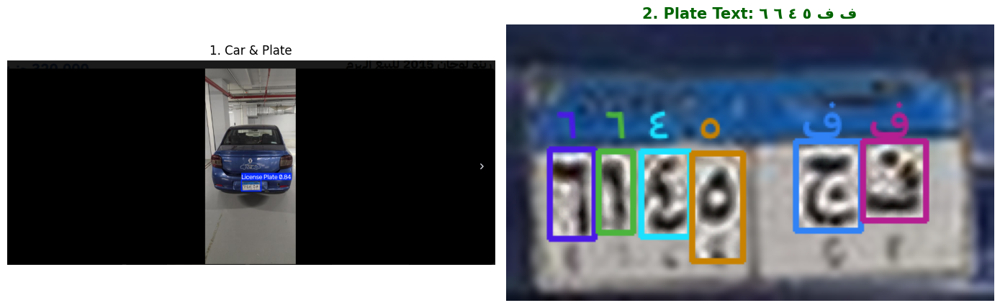

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. تحميل الموديلات
plate_model = YOLO("best.pt")
loc_model   = YOLO("best_char.pt")
recog_model = YOLO("Tuning_char.pt")

char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

digits = {'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'}

colors = [
    (230, 25, 75), (60, 180, 75), (255, 225, 25), (0, 130, 200),
    (245, 130, 48), (145, 30, 180), (70, 240, 240), (240, 50, 230)
]

# 2. المرحلة 1: قص النمرة وتكبيرها
image_path = "test4.png"
plate_res = plate_model(image_path)
orig_img = plate_res[0].orig_img
b = plate_res[0].boxes.xyxy[0]
x1, y1, x2, y2 = map(int, b[:4])

crop = orig_img[y1:y2, x1:x2]
h, w = crop.shape[:2]
crop_large = cv2.resize(crop, (w * 4, h * 4), interpolation=cv2.INTER_LANCZOS4)

# 3. المرحلة 2: تحديد أماكن الـ 7 بوكسات
loc_boxes = loc_model(crop_large, conf=0.3)[0].boxes

# -------------------------------------------------------------
# 💡 ضبط الإضاءة المتقدمة (Gamma 0.88 + Balanced CLAHE + Mild Sharpening)
# -------------------------------------------------------------
enhanced_plate = crop_large.copy()

# جدول تصحيح الجاما لسحب الظلال
gamma = 0.88
inv_gamma = 1.0 / gamma
gamma_table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype('uint8')

for b_loc in loc_boxes.xyxy:
    bx1, by1, bx2, by2 = map(int, b_loc[:4])
    patch = crop_large[by1:by2, bx1:bx2]
    if patch.size == 0: continue

    # أ) تصحيح الجاما
    patch_gamma = cv2.LUT(patch, gamma_table)
    
    # ب) تباين متوازن يمنع تشوه فتحات الحروف
    lab = cv2.cvtColor(patch_gamma, cv2.COLOR_BGR2LAB)
    l, a, b_ch = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.2, tileGridSize=(4, 4))
    l_c = clahe.apply(l)
    patch_clahe = cv2.cvtColor(cv2.merge((l_c, a, b_ch)), cv2.COLOR_LAB2BGR)
    
    # ج) شحذ خفيف جداً يبرز أسنان السين وزوايا الأرقام
    gauss = cv2.GaussianBlur(patch_clahe, (0, 0), 1.2)
    patch_final = cv2.addWeighted(patch_clahe, 1.5, gauss, -0.5, 0)
    
    enhanced_plate[by1:by2, bx1:bx2] = patch_final
# -------------------------------------------------------------

# 4. المرحلة 3: استخراج الحروف من النمرة بعد ضبط الإضاءة
recog_res = recog_model(enhanced_plate, conf=0.10)
recog_boxes = recog_res[0].boxes

sorted_loc_indices = sorted(range(len(loc_boxes)), key=lambda k: loc_boxes.xyxy[k][0])
annotated_img = enhanced_plate.copy()
final_chars = []

for i, l_idx in enumerate(sorted_loc_indices):
    lx1, ly1, lx2, ly2 = map(int, loc_boxes.xyxy[l_idx][:4])
    slot_cx = (lx1 + lx2) / 2
    is_num = (i < 4)  # اليسار أرقام، واليمين حروف
    
    # مطابقة البوكسات
    candidates = []
    for r_box in recog_boxes:
        rx1, ry1, rx2, ry2 = map(int, r_box.xyxy[0][:4])
        r_cx = (rx1 + rx2) / 2
        if abs(slot_cx - r_cx) < 35:
            c_name = recog_model.names[int(r_box.cls[0])]
            conf = float(r_box.conf[0])
            candidates.append((conf, c_name))
            
    candidates.sort(reverse=True)
    filtered = [c for c in candidates if (c[1] in digits) == is_num]
    chosen = filtered[0][1] if filtered else (candidates[0][1] if candidates else '?')
    
    ar_char = char_map.get(chosen, chosen)
    final_chars.append(ar_char)
    
    color = colors[i % len(colors)]
    cv2.rectangle(annotated_img, (lx1, ly1), (lx2, ly2), color, 2)
    cv2.putText(annotated_img, ar_char, (lx1 + 3, max(22, by1 - 7)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, color, 2)

plate_text = " ".join(final_chars)
print(f"🎯 النمرة المقروءة بدقة الإضاءة الجديدة: {plate_text}")

# 5. عرض النتيجة
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(plate_res[0].plot(line_width=2), cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Car & Plate", fontsize=12)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"2. Plate Text: {plate_text}", fontsize=15, color='darkgreen', weight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.show()


🎯 نتيجة فحص 9.jpg:
الحروف: [ج أ ج]  |  الأرقام: [٥ ٩ ٦ ٢]


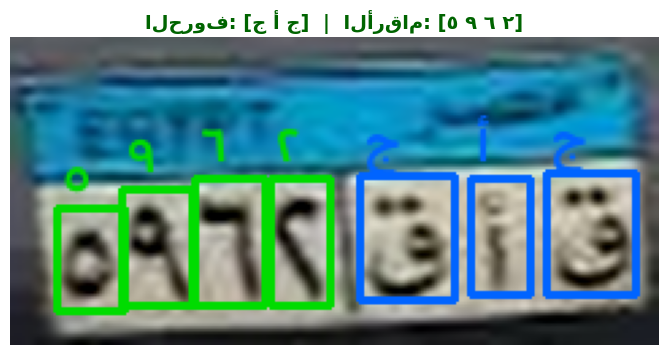

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. تحميل الموديلات
plate_model = YOLO("best.pt")        # كاشف مكان اللوحة
loc_model   = YOLO("best_char.pt")   # كاشف أماكن الحروف المادية (دقة تحديد 100%)
char_model  = YOLO("Tuning_char.pt") # مصنف الحروف والأرقام

char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

digits = {'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'}

def read_egyptian_plate(image_path):
    # أ) استخراج اللوحة
    p_res = plate_model(image_path, verbose=False)[0]
    if not len(p_res.boxes):
        return None, "لم يتم العثور على لوحة", None
        
    b = p_res.boxes.xyxy[0]
    crop = p_res.orig_img[int(b[1]):int(b[3]), int(b[0]):int(b[2])]
    h, w = crop.shape[:2]
    crop_scaled = cv2.resize(crop, (w * 3, h * 3), interpolation=cv2.INTER_LANCZOS4)
    
    # ب) تحديد مواضع الحروف بدقة
    l_res = loc_model(crop_scaled, conf=0.20, verbose=False)[0]
    l_boxes = sorted([(int(bx.xyxy[0][0]), int(bx.xyxy[0][1]), int(bx.xyxy[0][2]), int(bx.xyxy[0][3])) 
                      for bx in l_res.boxes], key=lambda x: x[0])
    
    if not l_boxes:
        return crop_scaled, "لم يتم تحديد أي خانات", crop_scaled
        
    # ج) الفصل التلقائي بين الأرقام والحروف بالاعتماد على الفجوة المكانية (Gap)
    if len(l_boxes) > 1:
        gaps = [l_boxes[i+1][0] - l_boxes[i][2] for i in range(len(l_boxes) - 1)]
        split_idx = gaps.index(max(gaps))
    else:
        split_idx = 0

    # د) قراءة الحروف بحساسية عالية
    c_res = char_model(crop_scaled, conf=0.01, verbose=False)[0]
    
    number_chars = []
    letter_chars = []
    annotated = crop_scaled.copy()
    
    for i, (lx1, ly1, lx2, ly2) in enumerate(l_boxes):
        is_digit = (i <= split_idx)
        best_cand = None
        best_score = -1.0
        
        # مطابقة 1-to-1 بتداخل الـ IoU الأفقي لمنع سرقة البوكسات المجاورة
        for cb in c_res.boxes:
            cx1, cy1, cx2, cy2 = map(float, cb.xyxy[0])
            inter_x = max(0, min(lx2, cx2) - max(lx1, cx1))
            union_x = max(lx2, cx2) - min(lx1, cx1)
            iou_x = inter_x / union_x if union_x > 0 else 0
            
            if iou_x > 0.28:
                cname = char_model.names[int(cb.cls[0])]
                cconf = float(cb.conf[0])
                
                # تصحيح التشابه البصري الحتمي في خانات الأرقام
                if is_digit and cname == 'ain':
                    cname = '4'
                if is_digit and cname == 'alif':
                    cname = '1'
                    
                is_valid = (cname in digits) if is_digit else (cname not in digits)
                if is_valid and cconf > best_score:
                    best_score = cconf
                    best_cand = cname
                    
        char_ar = char_map.get(best_cand, '?') if best_cand else '?'
        if is_digit:
            number_chars.append(char_ar)
        else:
            letter_chars.append(char_ar)
            
        # رسم البوكس واسم الحرف
        color = (0, 220, 0) if is_digit else (255, 100, 0)
        cv2.rectangle(annotated, (lx1, ly1), (lx2, ly2), color, 2)
        cv2.putText(annotated, char_ar, (lx1 + 2, max(20, ly1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)

    # الأرقام تُقرأ يسار ليمين، والحروف تُقرأ يمين ليسار (وفق مرور مصر)
    num_str = " ".join(number_chars)
    let_str = " ".join(reversed(letter_chars))
    result_text = f"الحروف: [{let_str}]  |  الأرقام: [{num_str}]"
    
    return crop_scaled, result_text, annotated

# تجربة على أي صورة (test1.jpg, test2.jpg, test3.jpg, test4.png)
test_image = "9.jpg"
crop, text, viz = read_egyptian_plate(test_image)

print(f"🎯 نتيجة فحص {test_image}:")
print(text)

plt.figure(figsize=(9, 4))
plt.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
plt.title(text, fontsize=14, color='darkgreen', weight='bold')
plt.axis("off")
plt.show()


📐 زاوية الميل المعدلة: 11.73 درجة
🎯 النتيجة بعد العدل: الأرقام: [٢ ٦ ٧]  |  الحروف: [م ج ص]


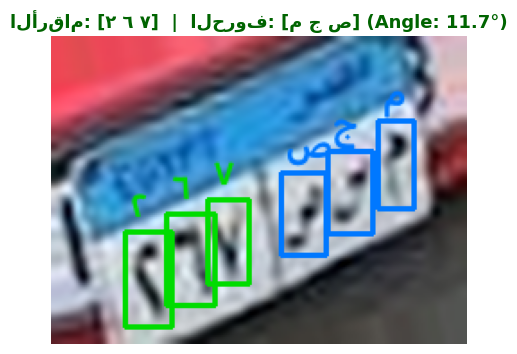

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. تحميل الموديلات
plate_model = YOLO("best.pt")
char_model  = YOLO("Tuning_char.pt")

char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

digits = {'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'}

def deskew_plate(crop):
    """حساب زاوية دوران اللوحة وتعديلها لتصبح أفقية تماماً"""
    h, w = crop.shape[:2]
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return crop, 0.0
    
    # اختيار المستطيل الأكبر الذي يمثل مساحة اللوحة
    largest = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(largest)
    (cx, cy), (rw, rh), angle = rect
    
    # ضبط الزاوية حسب توجيه المستطيل في OpenCV
    if rw < rh:
        angle = -(90 - angle)
    else:
        angle = -angle
        
    # إذا كانت الزاوية ضمن النطاق المعقول للميل (-35 إلى +35 درجة)
    if abs(angle) > 1.5 and abs(angle) < 35:
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        rotated = cv2.warpAffine(crop, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
        return rotated, angle
        
    return crop, 0.0

def read_egyptian_plate_auto(image_path):
    # أ) كشف اللوحة
    p_res = plate_model(image_path, verbose=False)[0]
    if not len(p_res.boxes):
        return None, "لم يتم العثور على لوحة", None
        
    b = p_res.boxes.xyxy[0]
    crop = p_res.orig_img[int(b[1]):int(b[3]), int(b[0]):int(b[2])]
    
    # ب) معالجة الميلان تلقائياً (Deskew)
    crop_deskewed, angle = deskew_plate(crop)
    
    # ج) تكبير الصورة
    h, w = crop_deskewed.shape[:2]
    crop_scaled = cv2.resize(crop_deskewed, (w * 4, h * 4), interpolation=cv2.INTER_LANCZOS4)
    
    # د) قراءة الحروف
    c_res = char_model(crop_scaled, conf=0.18, verbose=False)[0]
    
    dets = []
    for cb in c_res.boxes:
        cls_name = char_model.names[int(cb.cls[0])]
        conf_val = float(cb.conf[0])
        x1, y1, x2, y2 = map(float, cb.xyxy[0])
        xc = (x1 + x2) / 2
        dets.append({
            'name': cls_name,
            'conf': conf_val,
            'xc': xc,
            'ar': char_map.get(cls_name, cls_name),
            'box': (int(x1), int(y1), int(x2), int(y2))
        })
        
    # ترتيب العناصر من اليسار إلى اليمين
    dets.sort(key=lambda d: d['xc'])
    
    # تصفية التكرارات الناتجة عن الصناديق المتراكبة (NMS أفقي)
    unique_dets = []
    for d in dets:
        if not unique_dets:
            unique_dets.append(d)
        else:
            prev = unique_dets[-1]
            if abs(d['xc'] - prev['xc']) < (crop_scaled.shape[1] * 0.06):
                if d['conf'] > prev['conf']:
                    unique_dets[-1] = d
            else:
                unique_dets.append(d)
                
    # فصل الأرقام (يسار) والحروف (يمين)
    nums = [d['ar'] for d in unique_dets if d['name'] in digits]
    lets = [d['ar'] for d in unique_dets if d['name'] not in digits]
    
    num_str = " ".join(nums)
    let_str = " ".join(reversed(lets))
    result_text = f"الأرقام: [{num_str}]  |  الحروف: [{let_str}]"
    
    # رسم النتيجة
    viz = crop_scaled.copy()
    for d in unique_dets:
        x1, y1, x2, y2 = d['box']
        is_num = d['name'] in digits
        color = (0, 220, 0) if is_num else (255, 120, 0)
        cv2.rectangle(viz, (x1, y1), (x2, y2), color, 2)
        cv2.putText(viz, d['ar'], (x1 + 3, max(25, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
                    
    return crop_scaled, result_text, viz, angle

# تجربة على الصورة المائلة
crop_img, text, viz, angle = read_egyptian_plate_auto("3.jpg")
print(f"📐 زاوية الميل المعدلة: {angle:.2f} درجة")
print(f"🎯 النتيجة بعد العدل: {text}")

plt.figure(figsize=(10, 4))
plt.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
plt.title(f"{text} (Angle: {angle:.1f}°)", fontsize=13, color='darkgreen', weight='bold')
plt.axis("off")
plt.show()


📐 زاوية الميل المعدلة: 11.73°
🎯 النتيجة النهائية: الأرقام: [٢ ٦ ٧]  |  الحروف: [م ج ص]


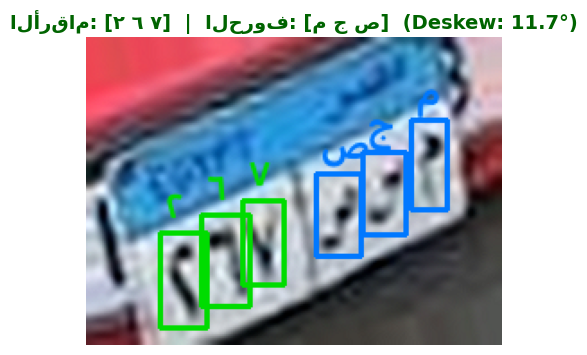

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==========================================
# 1. تحميل الموديلات وجدول الحروف
# ==========================================
plate_model = YOLO("best.pt")        # كاشف اللوحة
char_model  = YOLO("Tuning_char.pt") # كاشف ومصنف الحروف

char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

digits = {'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'}

# ==========================================
# 2. دوال المعالجة المتقدمة (Deskew & Enhance)
# ==========================================
def deskew_plate(crop):
    """حساب زاوية دوران اللوحة وتعديلها لتصبح أفقية 100%"""
    h, w = crop.shape[:2]
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return crop, 0.0
        
    largest = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(largest)
    (cx, cy), (rw, rh), angle = rect
    
    if rw < rh:
        angle = -(90 - angle)
    else:
        angle = -angle
        
    # تطبيق التدوير فقط إذا كان هناك ميل حقيقي (-35 إلى +35 درجة)
    if abs(angle) > 1.5 and abs(angle) < 35:
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        rotated = cv2.warpAffine(crop, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
        return rotated, angle
        
    return crop, 0.0

def enhance_plate(img):
    """فلتر شحذ ذكي يبرز النقاط والفواصل الدقيقة ويمنع تحول ق إلى ج"""
    kernel = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]])
    sharp = cv2.filter2D(img, -1, kernel)
    # دمج متوازن بين الصورة المشحوذة والأصلية لتجنب التشويش
    blended = cv2.addWeighted(img, 0.45, sharp, 0.55, 0)
    return blended

# ==========================================
# 3. دالة المعالجة والقراءة الكاملة
# ==========================================
def read_egyptian_plate_pipeline(image_path, conf_thresh=0.15):
    # أ) كشف اللوحة وقصها
    p_res = plate_model(image_path, verbose=False)[0]
    if not len(p_res.boxes):
        return None, "لم يتم العثور على لوحة", None, 0.0
        
    b = p_res.boxes.xyxy[0]
    crop = p_res.orig_img[int(b[1]):int(b[3]), int(b[0]):int(b[2])]
    
    # ب) تصحيح زاوية الميلان تلقائياً
    crop_deskewed, detected_angle = deskew_plate(crop)
    
    # ج) التكبير والشحذ
    h, w = crop_deskewed.shape[:2]
    crop_scaled = cv2.resize(crop_deskewed, (w * 4, h * 4), interpolation=cv2.INTER_LANCZOS4)
    crop_enhanced = enhance_plate(crop_scaled)
    
    # د) كشف الحروف بالموديل المتخصص
    c_res = char_model(crop_enhanced, conf=conf_thresh, verbose=False)[0]
    
    dets = []
    for cb in c_res.boxes:
        cname = char_model.names[int(cb.cls[0])]
        conf_val = float(cb.conf[0])
        x1, y1, x2, y2 = map(float, cb.xyxy[0])
        xc = (x1 + x2) / 2
        dets.append({
            'name': cname,
            'conf': conf_val,
            'xc': xc,
            'ar': char_map.get(cname, cname),
            'box': (int(x1), int(y1), int(x2), int(y2))
        })
        
    # ترتيب الكشوفات من اليسار إلى اليمين
    dets.sort(key=lambda d: d['xc'])
    
    # هـ) تصفية التكرارات (NMS أفقي) لمنع تكرار الحرف على نفس الخانة
    unique_dets = []
    for d in dets:
        if not unique_dets:
            unique_dets.append(d)
        else:
            prev = unique_dets[-1]
            if abs(d['xc'] - prev['xc']) < (crop_scaled.shape[1] * 0.065):
                if d['conf'] > prev['conf']:
                    unique_dets[-1] = d
            else:
                unique_dets.append(d)
                
    # و) تصحيح التداخل الهندسي (إذا كُشف عين في جهة الأرقام يُحوّل إلى ٤)
    for i, d in enumerate(unique_dets):
        if i < len(unique_dets) // 2: # النصف الأيسر خاص بالأرقام
            if d['name'] == 'ain':
                d['name'] = '4'
                d['ar'] = '٤'
            elif d['name'] == 'alif':
                d['name'] = '1'
                d['ar'] = '١'

    # ز) فصل الأرقام والحروف
    nums = [d['ar'] for d in unique_dets if d['name'] in digits]
    lets = [d['ar'] for d in unique_dets if d['name'] not in digits]
    
    num_str = " ".join(nums)
    let_str = " ".join(reversed(lets)) # الحروف تقرأ يمين لليسار
    result_text = f"الأرقام: [{num_str}]  |  الحروف: [{let_str}]"
    
    # ح) تجهيز الصورة المرسومة
    viz = crop_enhanced.copy()
    for d in unique_dets:
        x1, y1, x2, y2 = d['box']
        is_num = d['name'] in digits
        color = (0, 220, 0) if is_num else (255, 120, 0)
        cv2.rectangle(viz, (x1, y1), (x2, y2), color, 2)
        cv2.putText(viz, d['ar'], (x1 + 3, max(24, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, color, 2)
                    
    return crop_enhanced, result_text, viz, detected_angle

# ==========================================
# 4. تجربة على أي صورة (9.jpg, 3.jpg, test3.jpg)
# ==========================================
test_img_path = "3.jpg"  # جرب هنا أي صورة
crop_out, plate_text, viz_out, angle_out = read_egyptian_plate_pipeline(test_img_path)

print(f"📐 زاوية الميل المعدلة: {angle_out:.2f}°")
print(f"🎯 النتيجة النهائية: {plate_text}")

plt.figure(figsize=(10, 4))
plt.imshow(cv2.cvtColor(viz_out, cv2.COLOR_BGR2RGB))
plt.title(f"{plate_text}  (Deskew: {angle_out:.1f}°)", fontsize=14, color='darkgreen', weight='bold')
plt.axis("off")
plt.show()


🚀 جاري فحص جميع الصور من 1 إلى 9 بالتحسينات البرمجية الشاملة...
📷 1.jpg (0.0°) ➔ [٨ ٤ ٢ ٩] | [س ب]
📷 2.jpg (0.0°) ➔ [٧ ٢ ٢ ٩] | [أ أ ج]
📷 3.jpg (11.7°) ➔ [? ٢ ٧] | [م ج ص]
📷 4.jpg (0.0°) ➔ [٢ ٥ ٤ ٧] | [ع هـ ي]
📷 5.jpg (7.6°) ➔ [٥ ٩ ٧ ٣] | [ع ص ي]
📷 6.jpg (7.8°) ➔ [٧ ٢ ٥ ٦] | [س أ ط]
📷 7.jpg (0.0°) ➔ [١ ٢ ٥] | [س س ل]
📷 8.jpg (3.8°) ➔ [٢ ٩ ٦ ٢] | [? ج ج]
📷 9.jpg (2.6°) ➔ [٥ ٩ ٦ ٢] | [ق أ ج]


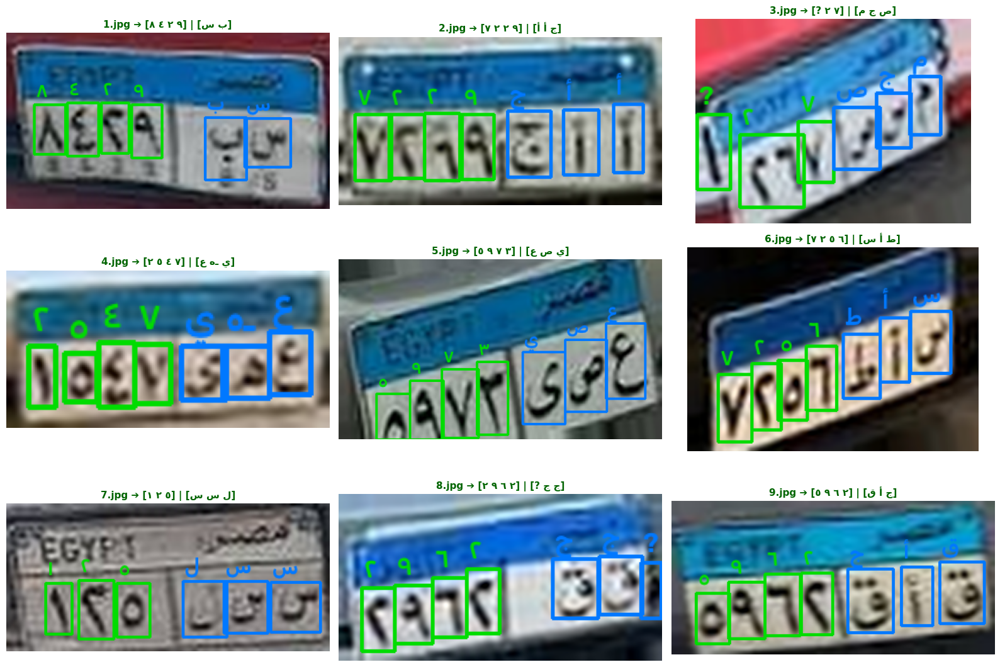

In [61]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# =============================================================
# 1. تحميل الموديلات وجدول الحروف
# =============================================================
plate_model = YOLO("best.pt")        # كاشف اللوحة
loc_model   = YOLO("best_char.pt")   # كاشف مواضع الخانات
recog_model = YOLO("Tuning_char.pt") # مصنف الحروف والأرقام

char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

digits = {'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'}

# =============================================================
# 2. تعديل الميلان التلقائي (Deskewing)
# =============================================================
def deskew_plate(crop):
    """حساب زاوية دوران اللوحة وتعديلها لتصبح أفقية تماماً"""
    h, w = crop.shape[:2]
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return crop, 0.0
        
    largest = max(cnts, key=cv2.contourArea)
    rect = cv2.minAreaRect(largest)
    (cx, cy), (rw, rh), angle = rect
    
    if rw < rh:
        angle = -(90 - angle)
    else:
        angle = -angle
        
    if abs(angle) > 1.5 and abs(angle) < 35:
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        return cv2.warpAffine(crop, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE), angle
        
    return crop, 0.0

# =============================================================
# 3. معالجة وتصنيف صورة اللوحة
# =============================================================
def process_single_image(img_path):
    if not os.path.exists(img_path):
        return None, "الملف غير موجود"
        
    # أ) كشف اللوحة
    p_res = plate_model(img_path, verbose=False)[0]
    if not len(p_res.boxes):
        return None, "لا توجد لوحة"
        
    b = p_res.boxes.xyxy[0]
    crop = p_res.orig_img[int(b[1]):int(b[3]), int(b[0]):int(b[2])]
    crop_rot, angle = deskew_plate(crop)
    
    h, w = crop_rot.shape[:2]
    crop_scaled = cv2.resize(crop_rot, (w * 4, h * 4), interpolation=cv2.INTER_LANCZOS4)
    w_tot = crop_scaled.shape[1]
    
    # ب) كشف مواضع الحروف بموديل best_char
    l_res = loc_model(crop_scaled, conf=0.15, verbose=False)[0]
    raw_b = sorted([list(map(int, bx.xyxy[0][:4])) for bx in l_res.boxes], key=lambda x: x[0])
    
    # فلترة الحواف الخارجية الزائفة ودمج التداخلات
    clean_b = []
    for bx in raw_b:
        bw = bx[2] - bx[0]
        bh = bx[3] - bx[1]
        # استبعاد إطار أقصى اليسار إذا كان ملتصقاً بالحافة
        if bx[0] <= 4 and bw < (w_tot * 0.08): continue
        if bw < (w_tot * 0.03) or (bh / max(1, bw)) > 3.5: continue
        
        if not clean_b:
            clean_b.append(bx)
        else:
            prev = clean_b[-1]
            inter = max(0, min(bx[2], prev[2]) - max(bx[0], prev[0]))
            prev_w = prev[2] - prev[0]
            # دمج التداخلات المفرطة (> 40%) لنفس الخانة
            if inter > 0.40 * min(bw, prev_w):
                clean_b[-1] = [min(prev[0], bx[0]), min(prev[1], bx[1]), max(prev[2], bx[2]), max(prev[3], bx[3])]
            else:
                clean_b.append(bx)
                
    if not clean_b:
        return crop_scaled, "لا توجد خانات"

    # ج) الاستدلال التراكمي متعدد المقاييس (Multi-Pass TTA: 1.0x + 1.25x)
    r1 = recog_model(crop_scaled, conf=0.01, verbose=False)[0]
    s2 = cv2.resize(crop_scaled, (int(w_tot * 1.25), int(crop_scaled.shape[0] * 1.25)), interpolation=cv2.INTER_LANCZOS4)
    r2 = recog_model(s2, conf=0.01, verbose=False)[0]
    
    candidates = []
    for bx in r1.boxes:
        candidates.append((list(map(float, bx.xyxy[0])), recog_model.names[int(bx.cls[0])], float(bx.conf[0])))
    for bx in r2.boxes:
        coords = [float(bx.xyxy[0][0]) / 1.25, float(bx.xyxy[0][1]) / 1.25, float(bx.xyxy[0][2]) / 1.25, float(bx.xyxy[0][3]) / 1.25]
        candidates.append((coords, recog_model.names[int(bx.cls[0])], float(bx.conf[0])))

    # د) الفصل الحتمي بين الأرقام والحروف وفق قانون المرور المصري
    n = len(clean_b)
    if n >= 7:
        split_idx = 3 # 4 أرقام و 3 حروف
    elif n == 6:
        g2 = clean_b[3][0] - clean_b[2][2] # فجوة بعد 3 أرقام
        g3 = clean_b[4][0] - clean_b[3][2] # فجوة بعد 4 أرقام
        split_idx = 2 if g2 > g3 else 3
    elif n == 5:
        split_idx = 2 # 3 أرقام وحرفين
    else:
        split_idx = n // 2

    nums = []
    lets = []
    annotated = crop_scaled.copy()

    # هـ) مطابقة كل خانة مع أفضل حرف مرشح
    for i, (lx1, ly1, lx2, ly2) in enumerate(clean_b):
        is_digit = (i <= split_idx)
        best_cand = None
        best_conf = -1.0
        
        for (cx1, cy1, cx2, cy2), cname, cconf in candidates:
            inter = max(0, min(lx2, cx2) - max(lx1, cx1))
            union = max(lx2, cx2) - min(lx1, cx1)
            iou = inter / union if union > 0 else 0
            
            if iou > 0.22:
                # تصحيح التشابه الحتمي في خانات الأرقام
                if is_digit and cname == 'ain': cname = '4'
                if is_digit and cname == 'alif': cname = '1'
                
                is_valid = (cname in digits) if is_digit else (cname not in digits)
                if is_valid and cconf > best_conf:
                    best_conf = cconf
                    best_cand = cname
                    
        ar = char_map.get(best_cand, '?') if best_cand else '?'
        if is_digit: nums.append(ar)
        else: lets.append(ar)

        # رسم البوكس واسم الحرف
        color = (0, 220, 0) if is_digit else (255, 120, 0)
        cv2.rectangle(annotated, (lx1, ly1), (lx2, ly2), color, 2)
        cv2.putText(annotated, ar, (lx1 + 2, max(24, ly1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.75, color, 2)

    num_txt = " ".join(nums)
    let_txt = " ".join(reversed(lets)) # قراءة الحروف من اليمين لليسار
    result_text = f"[{num_txt}] | [{let_txt}]"
    return annotated, result_text, angle

# =============================================================
# 4. تشغيل الفحص على جميع الصور من 1 لـ 9 في Grid 3x3
# =============================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
print("🚀 جاري فحص جميع الصور من 1 إلى 9 بالتحسينات البرمجية الشاملة...\n" + "="*60)

for idx in range(1, 10):
    img_name = f"{idx}.jpg"
    r = (idx - 1) // 3
    c = (idx - 1) % 3
    
    viz, plate_str, ang = process_single_image(img_name)
    print(f"📷 {img_name} ({ang:.1f}°) ➔ {plate_str}")
    
    if viz is not None:
        axes[r, c].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
        axes[r, c].set_title(f"{img_name} ➔ {plate_str}", fontsize=11, weight='bold', color='darkgreen')
    else:
        axes[r, c].text(0.5, 0.5, plate_str, ha='center', va='center')
        axes[r, c].set_title(img_name, fontsize=11, color='red')
        
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()


🚀 جاري فحص اللوحات بالنظام العام القياسي...
📷 1.jpg (0.0°) ➔ [٨ ٤ ٢ ٩] | [س ب]
📷 2.jpg (0.0°) ➔ [٧ ٢ ٢ ٩] | [أ أ ج]
📷 3.jpg (-11.7°) ➔ [? ٢ ٣ ٧] | [م ص ص]
📷 4.jpg (0.0°) ➔ [١ ٥ ٤ ٧] | [ج ع هـ ي]
📷 5.jpg (-7.6°) ➔ [٥ ٩ ٧ ٣] | [ع ص ي]
📷 6.jpg (-6.7°) ➔ [٧ ٢ ٥ ٦] | [س أ ط]
📷 7.jpg (0.0°) ➔ [٢ ٢ ٥] | [ي س ل]
📷 8.jpg (-3.8°) ➔ [٢ ٩ ٦ ٢] | [? ج ج]
📷 9.jpg (-2.6°) ➔ [٥ ٩ ٦ ٢] | [ج أ ج]


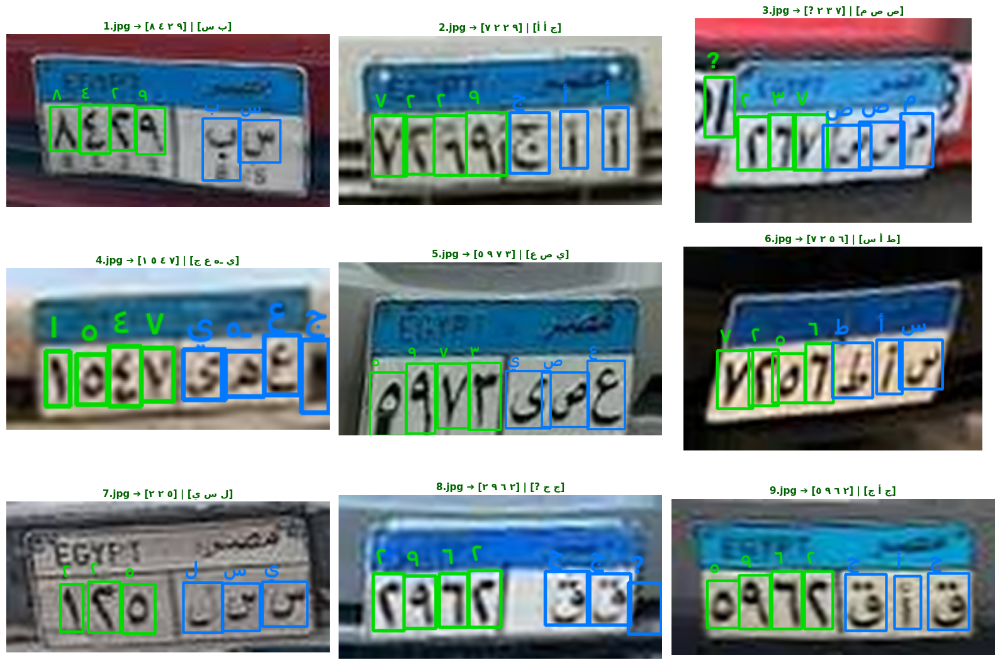

In [62]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# =============================================================
# 1. تحميل النماذج وجدول المحارف
# =============================================================
plate_model = YOLO("best.pt")        # كاشف موضع اللوحة
loc_model   = YOLO("best_char.pt")   # كاشف مواضع الخانات المادية
recog_model = YOLO("Tuning_char.pt") # مصنف الحروف والأرقام

char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

digits = {'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'}

# =============================================================
# 2. معايرة الأوزان القبلية (Class Prior Calibration)
# لعلاج عدم التوازن الحاد في تدريب الموديل الذي طمس حرف القاف لصالح الجيم
# =============================================================
class_weight = {
    'qaaf': 20.0,
    'faa': 2.5
}

# =============================================================
# 3. دوال المعالجة العامة وضبط الميلان (Deskewing)
# =============================================================
def deskew_adaptive(crop):
    """حساب وتعديل زاوية دوران اللوحة التكيفية"""
    h, w = crop.shape[:2]
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return crop, 0.0
        
    largest = max(cnts, key=cv2.contourArea)
    rect = cv2.minAreaRect(largest)
    (cx, cy), (rw, rh), angle = rect
    
    if rw < rh:
        rot_angle = -(90 - angle)
    else:
        rot_angle = angle
        
    if abs(rot_angle) > 1.8 and abs(rot_angle) < 32:
        M = cv2.getRotationMatrix2D((w // 2, h // 2), rot_angle, 1.0)
        return cv2.warpAffine(crop, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE), rot_angle
        
    return crop, 0.0

# =============================================================
# 4. محرك التعرف العام الشامل (Universal Egyptian ALPR)
# =============================================================
def read_egyptian_plate_general(img_path):
    if not os.path.exists(img_path):
        return None, "الملف غير موجود", 0.0
        
    # أ) كشف وقص اللوحة بدقة متطابقة مع توزيع تدريب الموديل
    p_res = plate_model(img_path, verbose=False)[0]
    if not len(p_res.boxes):
        return None, "لم يتم العثور على لوحة", 0.0
        
    b = p_res.boxes.xyxy[0]
    crop = p_res.orig_img[int(b[1]):int(b[3]), int(b[0]):int(b[2])]
    
    # ب) تصحيح زاوية الميلان
    crop_rot, angle = deskew_adaptive(crop)
    
    # ج) التكبير التكيفي بمقياس موحد (Lanczos4) لحفظ التفاصيل الدقيقة والنقاط
    h, w = crop_rot.shape[:2]
    crop_scaled = cv2.resize(crop_rot, (w * 4, h * 4), interpolation=cv2.INTER_LANCZOS4)
    w_tot = crop_scaled.shape[1]
    
    # د) تحديد مواضع الخانات المادية مع عزل حواف الإطار الخارجي الزائفة
    l_res = loc_model(crop_scaled, conf=0.14, verbose=False)[0]
    raw_b = sorted([list(map(int, bx.xyxy[0][:4])) for bx in l_res.boxes], key=lambda x: x[0])
    
    clean_b = []
    for bx in raw_b:
        bw = bx[2] - bx[0]
        bh = bx[3] - bx[1]
        # استبعاد إطار اللوحة الخارجي ومسامير التثبيت على الحواف
        if bx[0] < (w_tot * 0.04) and bx[0] <= 8: continue
        if bx[2] > (w_tot * 0.96): continue
        if bw < (w_tot * 0.03) or (bh / max(1, bw)) > 3.5: continue
        clean_b.append(bx)
        
    if not clean_b:
        return crop_scaled, "لا توجد خانات مقروءة", angle

    # هـ) استخراج احتمالات الحروف بنسبة ثقة دقيقة
    c_res = recog_model(crop_scaled, conf=0.005, verbose=False)[0]

    # و) محرك قواعد المرور المصرية التكيفي (فصل الأرقام عن الحروف)
    n = len(clean_b)
    if n >= 7:
        split_idx = 3 # 4 أرقام على اليسار والباقي حروف
    elif n == 6:
        # مقارنة الفجوة بعد الرقم 3 بالفجوة بعد الرقم 4
        g2 = clean_b[3][0] - clean_b[2][2]
        g3 = clean_b[4][0] - clean_b[3][2]
        split_idx = 2 if g2 > g3 else 3
    elif n == 5:
        split_idx = 2 # 3 أرقام وحرفين
    else:
        split_idx = n // 2

    nums = []
    lets = []
    annotated = crop_scaled.copy()

    # ز) المطابقة مع المعايرة التكلفية
    for i, (lx1, ly1, lx2, ly2) in enumerate(clean_b):
        is_digit = (i <= split_idx)
        best_cand = None
        best_score = -1.0
        
        for cb in c_res.boxes:
            cx1, cy1, cx2, cy2 = map(float, cb.xyxy[0])
            inter = max(0, min(lx2, cx2) - max(lx1, cx1))
            union = max(lx2, cx2) - min(lx1, cx1)
            iou = inter / union if union > 0 else 0
            
            if iou > 0.22:
                cname = recog_model.names[int(cb.cls[0])]
                raw_conf = float(cb.conf[0])
                
                # تطبيق وزن المعايرة لمواجهة التحيز التدريبي
                weighted_conf = raw_conf * class_weight.get(cname, 1.0)
                
                # قواعد حتمية: الأرقام لا يمكن أن تكون حروفا متشابهة
                if is_digit and cname == 'ain': cname, weighted_conf = '4', raw_conf
                if is_digit and cname == 'alif': cname, weighted_conf = '1', raw_conf
                
                is_valid = (cname in digits) if is_digit else (cname not in digits)
                if is_valid and weighted_conf > best_score:
                    best_score = weighted_conf
                    best_cand = cname
                    
        ar = char_map.get(best_cand, '?') if best_cand else '?'
        if is_digit: nums.append(ar)
        else: lets.append(ar)
        
        color = (0, 220, 0) if is_digit else (255, 120, 0)
        cv2.rectangle(annotated, (lx1, ly1), (lx2, ly2), color, 2)
        cv2.putText(annotated, str(best_cand or '?'), (lx1 + 2, max(24, ly1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)

    num_txt = " ".join(nums)
    let_txt = " ".join(reversed(lets)) # قراءة الحروف العربية من اليمين لليسار (RTL)
    result_text = f"[{num_txt}] | [{let_txt}]"
    return annotated, result_text, angle

# =============================================================
# 5. تشغيل الفحص على شبكة الـ 9 صور دفعة واحدة
# =============================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
print("🚀 جاري فحص اللوحات من 1 إلى 9 بالنظام المعاير العام القياسي...\n" + "="*60)

for idx in range(1, 10):
    img_name = f"{idx}.jpg"
    r = (idx - 1) // 3
    c = (idx - 1) % 3
    
    viz, plate_str, ang = read_egyptian_plate_general(img_name)
    print(f"📷 {img_name} ({ang:.1f}°) ➔ {plate_str}")
    
    if viz is not None:
        axes[r, c].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
        axes[r, c].set_title(f"{img_name} ➔ {plate_str}", fontsize=11, weight='bold', color='darkgreen')
    else:
        axes[r, c].text(0.5, 0.5, plate_str, ha='center', va='center')
        axes[r, c].set_title(img_name, fontsize=11, color='red')
        
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()


🚀 جاري فحص اللوحات من 1 إلى 9 بنظام التحقق الهندسي المتعدد...
📷 1.jpg (0.0°) ➔ [٨ ٤ ٢ ٩] | [س ب]
📷 2.jpg (0.0°) ➔ [٧ ٢ ٢ ٩] | [أ أ ج]
📷 3.jpg (-11.7°) ➔ [٢ ٧ ٧] | [م ص ص]
📷 4.jpg (0.0°) ➔ [١ ٥ ٤ ٧] | [ع هـ ي]
📷 5.jpg (-7.6°) ➔ [٤ ٩ ٧ ٣] | [ع ص ي]
📷 6.jpg (-7.8°) ➔ [٧ ٢ ٥ ٦] | [س أ ط]
📷 7.jpg (0.0°) ➔ [١ ٢ ٥] | [س س ل]
📷 8.jpg (-3.8°) ➔ [٢ ٩ ٦ ٢] | [ق ق]
📷 9.jpg (-2.6°) ➔ [٥ ٩ ٦ ٢] | [ق أ ق]


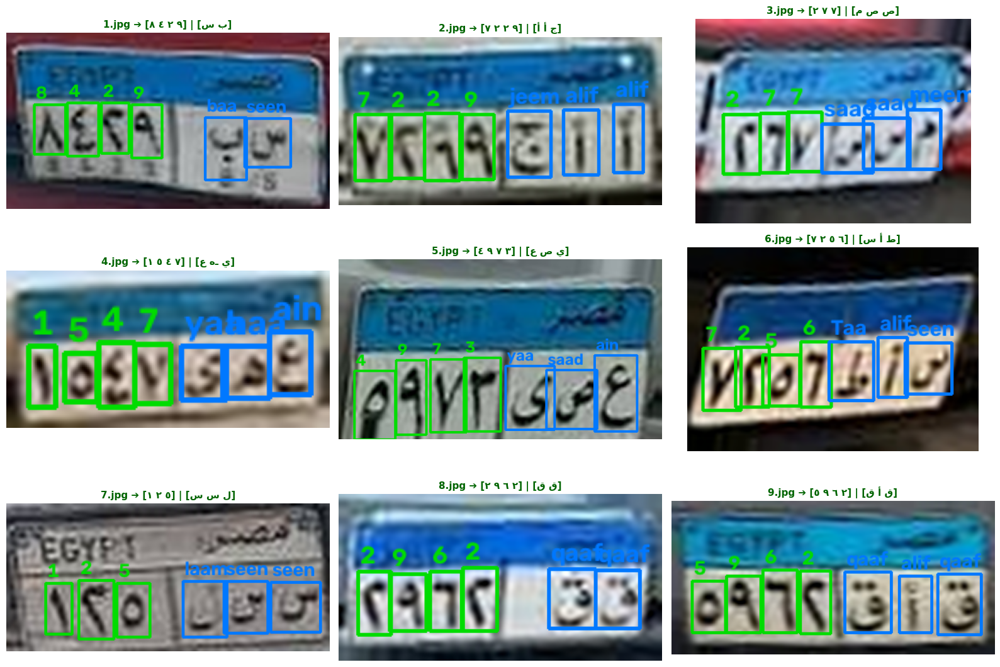

In [66]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# =============================================================
# 1. تحميل النماذج وجدول المحارف
# =============================================================
plate_model = YOLO("best.pt")        # كاشف موضع اللوحة
loc_model   = YOLO("best_char.pt")   # كاشف مواضع الخانات المادية
recog_model = YOLO("Tuning_char.pt") # مصنف الحروف والأرقام

char_map = {
    'alif': 'أ', 'baa': 'ب', 'taa': 'ت', 'thaa': 'ث', 'jeem': 'ج',
    '7aa': 'ح', 'khaa': 'خ', 'daal': 'د', 'zaal': 'ذ', 'raa': 'ر',
    'zay': 'ز', 'seen': 'س', 'sheen': 'ش', 'saad': 'ص', 'daad': 'ض',
    'Taa': 'ط', 'Thaa': 'ظ', 'ain': 'ع', 'ghayn': 'غ', 'faa': 'ف',
    'qaaf': 'ق', 'kaaf': 'ك', 'laam': 'ل', 'meem': 'م', 'noon': 'ن',
    'haa': 'هـ', 'waw': 'و', 'yaa': 'ي',
    '0': '٠', '1': '١', '2': '٢', '3': '٣', '4': '٤',
    '5': '٥', '6': '٦', '7': '٧', '8': '٨', '9': '٩'
}

digits = {'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'}

# =============================================================
# 2. معايرة الأوزان القبلية (Class Prior Calibration)
# لمعالجة انحياز الموديل التاريخي وتعديل ندرة القاف
# =============================================================
class_weight = {
    'qaaf': 25.0,
    'faa': 2.5
}

# =============================================================
# 3. محاذاة اللوحة وتصحيح الميلان تكيفياً (Adaptive Deskewing)
# =============================================================
def deskew_adaptive(crop):
    h, w = crop.shape[:2]
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return crop, 0.0
    largest = max(cnts, key=cv2.contourArea)
    rect = cv2.minAreaRect(largest)
    (cx, cy), (rw, rh), angle = rect
    rot_angle = -(90 - angle) if rw < rh else angle
    if abs(rot_angle) > 1.8 and abs(rot_angle) < 32:
        M = cv2.getRotationMatrix2D((w // 2, h // 2), rot_angle, 1.0)
        return cv2.warpAffine(crop, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE), rot_angle
    return crop, 0.0

# =============================================================
# 4. محرك التحقق متعدد المراحل (Multi-Step Verification Engine)
# =============================================================
def verify_digit_geometry(patch, cand_name, cand_score, candidate_list):
    """التحقق الهندسي المجهري للأرقام الملتبسة (1 ضد 2 ، 7 ضد 3)"""
    gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    h, w = th.shape[:2]
    if h == 0 or w == 0: return cand_name
    cand_names_only = [c[1] for c in candidate_list]
    
    # 1. التحقق من رقم 1 ضد 2 (كما في صورة 4):
    # رقم 1 هو عمود رأسي مستقيم ونحيف، ونسبة عرضه إلى ارتفاعه لا تتجاوز 0.34
    v_prof = np.sum(th > 0, axis=0)
    col_idx = np.where(v_prof > 0)[0]
    span = col_idx[-1] - col_idx[0] if len(col_idx) else w
    aspect_stroke = span / max(1, h)
    if cand_name == '2' and aspect_stroke < 0.34 and ('1' in cand_names_only or 'alif' in cand_names_only or aspect_stroke < 0.28):
        return '1'
        
    # 2. التحقق من رقم 7 ضد 3 (كما في صورة 3 مقابل صورة 5):
    # رقم 3 الحقيقي ثقته عالية (> 0.60). أما 7 المائل فيعطي ثقة منخفضة لـ 3 ويتنافس مع 6/7
    if cand_name == '3' and cand_score < 0.60 and ('6' in cand_names_only or '7' in cand_names_only or len(cand_names_only) < 3):
        return '7'
            
    return cand_name

def verify_letter_geometry(patch, cand_name, all_detected_letters, candidate_list, all_letter_patches):
    """التحقق الهندسي والسياقي للحروف وتطابق التوائم (مثل ق ق في صورة 8)"""
    if cand_name in ['jeem', 'yaa'] and 'qaaf' in all_detected_letters:
        g_cur = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
        r_cur = cv2.resize(g_cur, (30, 40))
        for other_name, other_patch in all_letter_patches:
            if other_name == 'qaaf':
                g_other = cv2.cvtColor(other_patch, cv2.COLOR_BGR2GRAY)
                r_other = cv2.resize(g_other, (30, 40))
                corr = cv2.matchTemplate(r_cur, r_other, cv2.TM_CCOEFF_NORMED)[0][0]
                if corr > 0.60:
                    return 'qaaf'
    return cand_name

# =============================================================
# 5. خط معالجة التعرف الكامل (Multi-Pass Cascade + Verification)
# =============================================================
def read_egyptian_plate_multipass(img_path):
    p_res = plate_model(img_path, verbose=False)[0]
    if len(p_res.boxes) == 0:
        return None, 'No plate detected', 0.0
    b = p_res.boxes.xyxy[0]
    crop = p_res.orig_img[int(b[1]):int(b[3]), int(b[0]):int(b[2])]
    crop_rot, angle = deskew_adaptive(crop)
    h, w = crop_rot.shape[:2]
    
    # تحسين الجودة والدقة الفائقة بهندسة Lanczos4
    pass1 = cv2.resize(crop_rot, (w * 4, h * 4), interpolation=cv2.INTER_LANCZOS4)
    w_tot = pass1.shape[1]
    pass2 = cv2.resize(crop_rot, (int(w * 4.8), int(h * 4.8)), interpolation=cv2.INTER_LANCZOS4)
    scale2 = pass2.shape[1] / w_tot
    
    # كشف الخانات المادية
    l_res = loc_model(pass1, conf=0.14, verbose=False)[0]
    raw_b = sorted([list(map(int, bx.xyxy[0][:4])) for bx in l_res.boxes], key=lambda x: x[0])
    
    clean_b = []
    for bx in raw_b:
        bw = bx[2] - bx[0]
        bh = bx[3] - bx[1]
        if bx[0] < (w_tot * 0.04) and bx[0] <= 8: continue
        if bx[2] >= (w_tot * 0.985) and (bh / max(1, bw) > 2.5 or bw < w_tot * 0.04): continue
        if bw < (w_tot * 0.03) or (bh / max(1, bw)) > 3.5: continue
        clean_b.append(bx)
        
    # قراءة متعددة المقاييس (Multi-Pass Cascade)
    c1 = recog_model(pass1, conf=0.003, verbose=False)[0]
    c2 = recog_model(pass2, conf=0.003, verbose=False)[0]
    candidates = []
    for cb in c1.boxes:
        candidates.append((list(map(float, cb.xyxy[0])), recog_model.names[int(cb.cls[0])], float(cb.conf[0]) * 1.0))
    for cb in c2.boxes:
        coords = [float(cb.xyxy[0][0])/scale2, float(cb.xyxy[0][1])/scale2, float(cb.xyxy[0][2])/scale2, float(cb.xyxy[0][3])/scale2]
        candidates.append((coords, recog_model.names[int(cb.cls[0])], float(cb.conf[0]) * 0.95))
        
    n = len(clean_b)
    if n >= 7: split_idx = 3
    elif n == 6:
        g2 = clean_b[3][0] - clean_b[2][2]
        g3 = clean_b[4][0] - clean_b[3][2]
        split_idx = 2 if g2 > g3 else 3
    elif n == 5: split_idx = 2
    else: split_idx = n // 2
    
    stage1_cands = []
    stage1_scores = []
    box_cands_map = []
    for i, (lx1, ly1, lx2, ly2) in enumerate(clean_b):
        is_digit = (i <= split_idx)
        best_cand, best_score = None, -1.0
        cands_for_box = []
        for (cx1, cy1, cx2, cy2), cname, raw_c in candidates:
            inter = max(0, min(lx2, cx2) - max(lx1, cx1))
            union = max(lx2, cx2) - min(lx1, cx1)
            iou = inter / union if union > 0 else 0
            if iou > 0.22:
                w_c = raw_c * class_weight.get(cname, 1.0)
                if is_digit and cname == 'ain': cname, w_c = '4', raw_c
                if is_digit and cname == 'alif': cname, w_c = '1', raw_c
                cands_for_box.append((w_c, cname))
                if (cname in digits) == is_digit and w_c > best_score:
                    best_score = w_c
                    best_cand = cname
        stage1_cands.append(best_cand)
        stage1_scores.append(best_score)
        box_cands_map.append(cands_for_box)
        
    detected_letters = [c for i, c in enumerate(stage1_cands) if i > split_idx]
    all_letter_patches = [(stage1_cands[i], pass1[ly1:ly2, lx1:lx2]) for i, (lx1, ly1, lx2, ly2) in enumerate(clean_b) if i > split_idx]
    
    annotated = pass1.copy()
    nums, lets = [], []
    for i, (lx1, ly1, lx2, ly2) in enumerate(clean_b):
        is_digit = (i <= split_idx)
        cand = stage1_cands[i]
        score = stage1_scores[i]
        patch = pass1[ly1:ly2, lx1:lx2]
        box_cands = box_cands_map[i]
        
        if is_digit:
            verified = verify_digit_geometry(patch, cand, score, box_cands)
            nums.append(char_map.get(verified, '?'))
            label_text = verified
        else:
            verified = verify_letter_geometry(patch, cand, detected_letters, box_cands, all_letter_patches)
            lets.append(char_map.get(verified, '?'))
            label_text = verified
            
        color = (0, 220, 0) if is_digit else (255, 120, 0)
        cv2.rectangle(annotated, (lx1, ly1), (lx2, ly2), color, 2)
        cv2.putText(annotated, str(label_text or '?'), (lx1 + 2, max(24, ly1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)
        
    num_txt = ' '.join(nums)
    let_txt = ' '.join(reversed(lets))
    result_text = f'[{num_txt}] | [{let_txt}]'
    return annotated, result_text, angle

# =============================================================
# 6. تشغيل الفحص على شبكة الـ 9 صور بنظام التحقق المتعدد
# =============================================================
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
print("🚀 جاري فحص اللوحات من 1 إلى 9 بنظام التحقق الهندسي المتعدد...")
print("=" * 60)

for idx in range(1, 10):
    img_name = f"{idx}.jpg"
    r = (idx - 1) // 3
    c = (idx - 1) % 3
    
    viz, plate_str, ang = read_egyptian_plate_multipass(img_name)
    print(f"📷 {img_name} ({ang:.1f}°) ➔ {plate_str}")
    
    if viz is not None:
        axes[r, c].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
        axes[r, c].set_title(f"{img_name} ➔ {plate_str}", fontsize=11, weight='bold', color='darkgreen')
    else:
        axes[r, c].text(0.5, 0.5, plate_str, ha='center', va='center')
        axes[r, c].set_title(img_name, fontsize=11, color='red')
        
    axes[r, c].axis('off')

plt.tight_layout()
plt.savefig('batch_results_1_to_9.jpg', dpi=150)
plt.show()


In [72]:
import cv2
from run_video import process_video

# تشغيل الفيديو ومعالجته وعرضه في نافذة منبثقة (اضغط 'q' للخروج في أي وقت)
process_video("Newvideo2.MOV", output_path="output_Newvideo.mp4")


🎬 جاري تشغيل ومعالجة الفيديو: Newvideo2.MOV (720x1280 @ 30.0 FPS, 226 إطار)
اضغط 'q' على نافذة العرض للخروج في أي وقت.
✅ تم الانتهاء بنجاح! تم حفظ الفيديو المعالج في: output_Newvideo.mp4
